# 01 - Tổng quan dữ liệu và chất lượng dữ liệu

**Mục tiêu:** hiểu nhanh bộ dữ liệu `diabetic_data.csv`: số dòng/cột, kiểu dữ liệu, missing value, duplicate, số bệnh nhân duy nhất, các cột ít thông tin và các cột nên bỏ/xử lý ở các bước sau.

Các cột tập trung trong notebook này:
- `encounter_id`, `patient_nbr`
- `race`, `gender`, `age`, `weight`
- `payer_code`, `medical_specialty`
- `examide`, `citoglipton`
- nhãn `readmitted`

## 1. Load dữ liệu

Trong file gốc, ký tự `?` được dùng để biểu diễn giá trị thiếu. Vì vậy khi đọc dữ liệu cần chuyển `?` thành `NaN` để pandas nhận diện missing value đúng cách.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập hiển thị để xem bảng rõ hơn trong notebook.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="Set2")

# Notebook nằm trong thư mục Exploratory Data Analysis, còn file CSV nằm ở thư mục gốc project.
data_candidates = [
    Path("diabetic_data.csv"),
    Path("..") / "diabetic_data.csv",
]

data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Không tìm thấy diabetic_data.csv. Hãy kiểm tra lại vị trí file dữ liệu.")

# na_values='?' giúp chuyển toàn bộ dấu ? thành missing value (NaN).
df = pd.read_csv(data_path, na_values="?")

print(f"Đã đọc dữ liệu từ: {data_path.resolve()}")
print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]:,} cột")

Đã đọc dữ liệu từ: D:\HocTap\KT&XLTT\CUOIKI\diabetic_data.csv
Kích thước dữ liệu: 101,766 dòng x 50 cột


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1912\2635980507.py:26: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, na_values="?")


## 2. Tổng quan dataset

Phần này kiểm tra kích thước dữ liệu, vài dòng đầu tiên, kiểu dữ liệu và thống kê mô tả cơ bản.

In [2]:
# Số dòng và số cột.
df.shape

(101766, 50)

In [3]:
# Xem nhanh 5 dòng đầu tiên.
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Kiểm tra tên cột, số lượng non-null và kiểu dữ liệu.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [5]:
# Thống kê mô tả cho các cột số.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.00,165201645.62,102640295.98,12522.00,84961194.00,152388987.00,230270887.50,443867222.00
patient_nbr,101766.00,54330400.69,38696359.35,135.00,23413221.00,45505143.00,87545949.75,189502619.00
admission_type_id,101766.00,2.02,1.45,1.00,1.00,1.00,3.00,8.00
discharge_disposition_id,101766.00,3.72,5.28,1.00,1.00,1.00,4.00,28.00
admission_source_id,101766.00,5.75,4.06,1.00,1.00,7.00,7.00,25.00
time_in_hospital,101766.00,4.40,2.99,1.00,2.00,4.00,6.00,14.00
num_lab_procedures,101766.00,43.10,19.67,1.00,31.00,44.00,57.00,132.00
num_procedures,101766.00,1.34,1.71,0.00,0.00,1.00,2.00,6.00
num_medications,101766.00,16.02,8.13,1.00,10.00,15.00,20.00,81.00
number_outpatient,101766.00,0.37,1.27,0.00,0.00,0.00,0.00,42.00


In [6]:
# Thống kê mô tả cho các cột phân loại/object.
df.describe(include="object").T

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1912\134445169.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
race,99493,5,Caucasian,76099
gender,101766,3,Female,54708
age,101766,10,[70-80),26068
weight,3197,9,[75-100),1336
payer_code,61510,17,MC,32439
medical_specialty,51817,72,InternalMedicine,14635
diag_1,101745,716,428,6862
diag_2,101408,748,276,6752
diag_3,100343,789,250,11555
max_glu_serum,5346,3,Norm,2597


## 3. Ý nghĩa các nhóm cột

Có thể chia các cột thành các nhóm chính để dễ phân tích và xử lý sau này.

In [7]:
# Chia nhóm cột theo ý nghĩa nghiệp vụ.
id_cols = ["encounter_id", "patient_nbr"]

demographic_cols = ["race", "gender", "age", "weight"]

admission_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "payer_code",
    "medical_specialty",
]

lab_diagnosis_cols = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
]

drug_cols = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
    "change",
    "diabetesMed",
]

target_col = ["readmitted"]

column_groups = {
    "ID": id_cols,
    "Nhân khẩu học": demographic_cols,
    "Nhập viện": admission_cols,
    "Xét nghiệm/chẩn đoán": lab_diagnosis_cols,
    "Thuốc": drug_cols,
    "Nhãn": target_col,
}

group_summary = []
for group_name, cols in column_groups.items():
    existing_cols = [col for col in cols if col in df.columns]
    group_summary.append({
        "nhom_cot": group_name,
        "so_cot": len(existing_cols),
        "danh_sach_cot": ", ".join(existing_cols),
    })

pd.DataFrame(group_summary)

,nhom_cot,so_cot,danh_sach_cot
0,ID,2,"encounter_id, patient_nbr"
1,Nhân khẩu học,4,"race, gender, age, weight"
2,Nhập viện,6,"admission_type_id, discharge_disposition_id, a..."
3,Xét nghiệm/chẩn đoán,12,"num_lab_procedures, num_procedures, num_medica..."
4,Thuốc,25,"metformin, repaglinide, nateglinide, chlorprop..."
5,Nhãn,1,readmitted


## 4. Kiểm tra missing value

Tính số lượng và phần trăm missing của từng cột, sau đó sắp xếp giảm dần để thấy cột nào thiếu nhiều nhất.

In [8]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
        "dtype": df.dtypes.astype(str),
        "unique_count": df.nunique(dropna=True),
    })
    .sort_values("missing_percent", ascending=False)
)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent,dtype,unique_count
weight,98569,96.86,str,9
max_glu_serum,96420,94.75,str,3
A1Cresult,84748,83.28,str,3
medical_specialty,49949,49.08,str,72
payer_code,40256,39.56,str,17
race,2273,2.23,str,5
diag_3,1423,1.40,str,789
diag_2,358,0.35,str,748
diag_1,21,0.02,str,716


In [9]:
# Tập trung vào các cột quan trọng được yêu cầu nhận xét.
focus_cols = [
    "encounter_id",
    "patient_nbr",
    "race",
    "gender",
    "age",
    "weight",
    "payer_code",
    "medical_specialty",
    "examide",
    "citoglipton",
    "readmitted",
]

missing_summary.loc[[col for col in focus_cols if col in missing_summary.index]]

,missing_count,missing_percent,dtype,unique_count
encounter_id,0,0.00,int64,101766
patient_nbr,0,0.00,int64,71518
race,2273,2.23,str,5
gender,0,0.00,str,3
age,0,0.00,str,10
weight,98569,96.86,str,9
payer_code,40256,39.56,str,17
medical_specialty,49949,49.08,str,72
examide,0,0.00,str,1
citoglipton,0,0.00,str,1


**Nhận xét nhanh:**
- `weight` thường thiếu rất nhiều nên khó dùng trực tiếp nếu không có chiến lược xử lý riêng.
- `payer_code` và `medical_specialty` cũng có tỷ lệ thiếu đáng kể, cần cân nhắc điền nhóm `Unknown` hoặc loại bỏ tùy mục tiêu mô hình.
- `race` có missing nhưng thường thấp hơn các cột trên, có thể xử lý bằng nhóm `Unknown`.
- Các cột không missing chưa chắc đã hữu ích; cần kiểm tra thêm số lượng unique value.

## 5. Biểu đồ missing value

Vẽ bar chart các cột có missing để trực quan hóa mức độ thiếu dữ liệu.

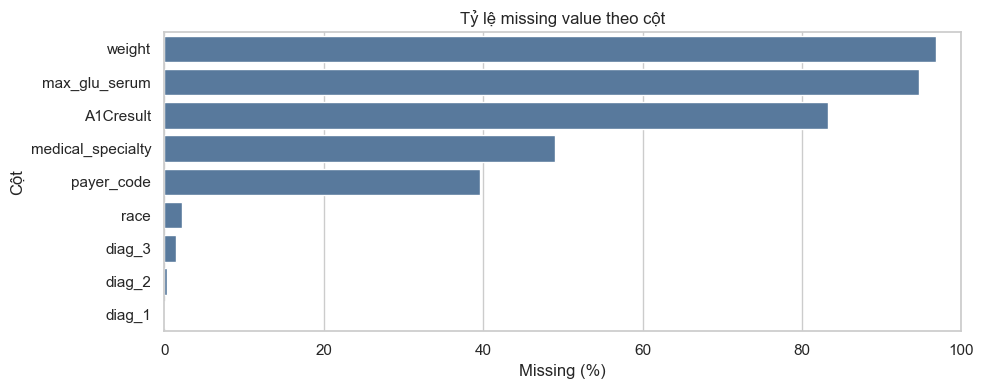

In [10]:
missing_plot_data = missing_summary[missing_summary["missing_count"] > 0].copy()

plt.figure(figsize=(10, max(4, 0.45 * len(missing_plot_data))))
sns.barplot(
    data=missing_plot_data.reset_index(names="column"),
    y="column",
    x="missing_percent",
    color="#4C78A8",
)
plt.title("Tỷ lệ missing value theo cột")
plt.xlabel("Missing (%)")
plt.ylabel("Cột")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 6. Kiểm tra duplicate

Kiểm tra duplicate ở 3 mức:
- Dòng trùng hoàn toàn.
- `encounter_id`: mã lượt khám/nhập viện, kỳ vọng là duy nhất cho mỗi dòng.
- `patient_nbr`: mã bệnh nhân, có thể lặp vì một bệnh nhân có thể nhập viện nhiều lần.

In [11]:
duplicate_rows = df.duplicated().sum()
duplicate_encounters = df.duplicated(subset=["encounter_id"]).sum()
duplicate_patients = df.duplicated(subset=["patient_nbr"]).sum()

duplicate_summary = pd.DataFrame({
    "kiem_tra": [
        "Dòng trùng hoàn toàn",
        "encounter_id bị lặp",
        "patient_nbr bị lặp",
    ],
    "so_luong": [duplicate_rows, duplicate_encounters, duplicate_patients],
    "ty_le_%": [
        duplicate_rows / len(df) * 100,
        duplicate_encounters / len(df) * 100,
        duplicate_patients / len(df) * 100,
    ],
})

duplicate_summary

,kiem_tra,so_luong,ty_le_%
0,Dòng trùng hoàn toàn,0,0.00
1,encounter_id bị lặp,0,0.00
2,patient_nbr bị lặp,30248,29.72


In [12]:
# Nếu có dòng trùng hoàn toàn, xem thử vài dòng để quyết định có cần loại bỏ không.
df[df.duplicated(keep=False)].head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


**Nhận xét:**
- Nếu `encounter_id` không bị lặp, cột này là ID của từng lượt nhập viện và không nên dùng làm feature dự đoán.
- `patient_nbr` bị lặp là hiện tượng hợp lý vì một bệnh nhân có thể có nhiều lần nhập viện. Tuy nhiên đây cũng là ID, không nên đưa trực tiếp vào mô hình.

## 7. Số bệnh nhân duy nhất

So sánh số lượt nhập viện (`encounter_id`) với số bệnh nhân duy nhất (`patient_nbr`).

In [13]:
n_rows = len(df)
n_encounters = df["encounter_id"].nunique()
n_patients = df["patient_nbr"].nunique()

patient_summary = pd.DataFrame({
    "chi_so": [
        "Số dòng/lượt ghi nhận",
        "Số encounter_id duy nhất",
        "Số patient_nbr duy nhất",
        "Số lượt nhập viện trung bình / bệnh nhân",
    ],
    "gia_tri": [
        n_rows,
        n_encounters,
        n_patients,
        n_rows / n_patients,
    ],
})

patient_summary

,chi_so,gia_tri
0,Số dòng/lượt ghi nhận,101766.00
1,Số encounter_id duy nhất,101766.00
2,Số patient_nbr duy nhất,71518.00
3,Số lượt nhập viện trung bình / bệnh nhân,1.42


In [14]:
# Phân bố số lần xuất hiện của mỗi bệnh nhân trong dataset.
visits_per_patient = df["patient_nbr"].value_counts()

visits_per_patient.describe()

count   71518.00
mean        1.42
std         1.09
min         1.00
25%         1.00
50%         1.00
75%         1.00
max        40.00
Name: count, dtype: float64

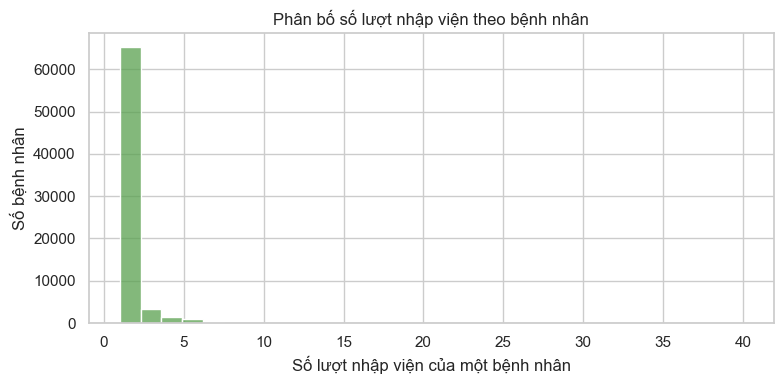

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(visits_per_patient, bins=30, color="#59A14F")
plt.title("Phân bố số lượt nhập viện theo bệnh nhân")
plt.xlabel("Số lượt nhập viện của một bệnh nhân")
plt.ylabel("Số bệnh nhân")
plt.tight_layout()
plt.show()

## 8. Kiểm tra unique value

Các cột có quá ít giá trị khác nhau, đặc biệt chỉ có 1 giá trị, thường gần như không có thông tin cho mô hình. Ngược lại, các cột ID có số unique gần bằng số dòng cũng không nên dùng trực tiếp vì dễ gây nhiễu/overfit.

In [16]:
unique_summary = (
    pd.DataFrame({
        "unique_count": df.nunique(dropna=False),
        "unique_percent": df.nunique(dropna=False) / len(df) * 100,
        "missing_percent": df.isna().mean() * 100,
        "dtype": df.dtypes.astype(str),
    })
    .sort_values(["unique_count", "unique_percent"], ascending=[True, True])
)

unique_summary

,unique_count,unique_percent,missing_percent,dtype
examide,1,0.00,0.00,str
citoglipton,1,0.00,0.00,str
acetohexamide,2,0.00,0.00,str
tolbutamide,2,0.00,0.00,str
troglitazone,2,0.00,0.00,str
glipizide-metformin,2,0.00,0.00,str
glimepiride-pioglitazone,2,0.00,0.00,str
metformin-rosiglitazone,2,0.00,0.00,str
metformin-pioglitazone,2,0.00,0.00,str
change,2,0.00,0.00,str


In [17]:
# Các cột chỉ có 1 giá trị duy nhất, gần như vô dụng cho phân tích dự đoán.
constant_cols = unique_summary[unique_summary["unique_count"] <= 1].index.tolist()
constant_cols

['examide', 'citoglipton']

In [18]:
# Các cột có ít giá trị khác nhau, phù hợp để xem phân phối category.
low_cardinality_cols = unique_summary[
    (unique_summary["unique_count"] > 1) & (unique_summary["unique_count"] <= 10)
].index.tolist()

low_cardinality_cols

['acetohexamide',
 'tolbutamide',
 'troglitazone',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'gender',
 'tolazamide',
 'readmitted',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'insulin',
 'glyburide-metformin',
 'race',
 'num_procedures',
 'admission_type_id',
 'age',
 'weight']

In [19]:
# Xem phân phối một số cột trọng tâm.
for col in ["race", "gender", "age", "weight", "payer_code", "medical_specialty", "examide", "citoglipton", "readmitted"]:
    if col in df.columns:
        print(f"\n===== {col} =====")
        display(
            df[col]
            .value_counts(dropna=False)
            .rename_axis(col)
            .reset_index(name="count")
            .assign(percent=lambda x: x["count"] / len(df) * 100)
            .head(20)
        )


===== race =====


,race,count,percent
0,Caucasian,76099,74.78
1,AfricanAmerican,19210,18.88
2,NaN,2273,2.23
3,Hispanic,2037,2.00
4,Other,1506,1.48
5,Asian,641,0.63



===== gender =====


,gender,count,percent
0,Female,54708,53.76
1,Male,47055,46.24
2,Unknown/Invalid,3,0.00



===== age =====


...

,examide,count,percent
0,No,101766,100.00



===== citoglipton =====


,citoglipton,count,percent
0,No,101766,100.00



===== readmitted =====


,readmitted,count,percent
0,NO,54864,53.91
1,>30,35545,34.93
2,<30,11357,11.16


In [20]:
# Các cột có unique gần bằng số dòng thường là ID hoặc gần-ID, không nên dùng trực tiếp làm feature.
near_id_cols = unique_summary[unique_summary["unique_percent"] >= 90].sort_values("unique_percent", ascending=False)
near_id_cols

,unique_count,unique_percent,missing_percent,dtype
encounter_id,101766,100.00,0.00,int64


**Nhận xét các cột cần chú ý:**
- `examide` và `citoglipton`: nếu chỉ có một giá trị duy nhất, nên bỏ vì không giúp phân biệt các quan sát.
- `encounter_id`: là mã lượt nhập viện, thường duy nhất gần như 100%, nên bỏ khỏi feature.
- `patient_nbr`: là mã bệnh nhân. Có thể dùng để phân tích số lần nhập viện, nhưng không nên dùng trực tiếp làm feature dự đoán.
- `weight`: nếu missing quá cao, nên bỏ hoặc chỉ giữ khi có cách xử lý chuyên biệt.
- `payer_code`, `medical_specialty`: thiếu nhiều nhưng vẫn có thể chứa thông tin; có thể thử 2 hướng: bỏ cột hoặc điền `Unknown` rồi đánh giá mô hình.

## 9. Kết luận file 1

Tổng hợp các vấn đề chất lượng dữ liệu và đề xuất xử lý ở các notebook sau.

In [21]:
# Tự động gợi ý cột nên bỏ dựa trên các kiểm tra ở trên.
high_missing_cols = missing_summary[missing_summary["missing_percent"] >= 50].index.tolist()
constant_cols = unique_summary[unique_summary["unique_count"] <= 1].index.tolist()
id_like_cols = ["encounter_id", "patient_nbr"]

recommended_drop_cols = sorted(set(high_missing_cols + constant_cols + id_like_cols))

recommendation = pd.DataFrame({
    "cot": recommended_drop_cols,
    "ly_do": [
        "; ".join(
            reason for reason in [
                "missing >= 50%" if col in high_missing_cols else "",
                "chỉ có 1 giá trị" if col in constant_cols else "",
                "cột định danh/ID" if col in id_like_cols else "",
            ]
            if reason
        )
        for col in recommended_drop_cols
    ],
})

recommendation

,cot,ly_do
0,A1Cresult,missing >= 50%
1,citoglipton,chỉ có 1 giá trị
2,encounter_id,cột định danh/ID
3,examide,chỉ có 1 giá trị
4,max_glu_serum,missing >= 50%
5,patient_nbr,cột định danh/ID
6,weight,missing >= 50%


### Kết luận đề xuất

- **Nên bỏ khỏi feature dự đoán:** `encounter_id`, `patient_nbr` vì đây là cột định danh, không mang ý nghĩa lâm sàng trực tiếp cho mô hình.
- **Nên bỏ nếu kết quả kiểm tra cho thấy chỉ có một giá trị:** `examide`, `citoglipton` vì không có khả năng phân biệt giữa các dòng dữ liệu.
- **Nên cân nhắc bỏ:** `weight` nếu tỷ lệ missing quá cao, vì việc điền missing có thể tạo nhiễu lớn.
- **Cần xử lý missing trước khi phân tích/mô hình hóa:** `race`, `payer_code`, `medical_specialty`, `diag_1`, `diag_2`, `diag_3` nếu các cột này được dùng ở bước sau.
- **Có thể giữ để phân tích:** `race`, `gender`, `age`, `medical_specialty`, `payer_code` sau khi xử lý missing phù hợp.
- **Lưu ý theo bệnh nhân:** một bệnh nhân có thể có nhiều lượt nhập viện, nên khi chia train/test ở các bước sau cần cân nhắc tránh rò rỉ thông tin giữa các lượt của cùng bệnh nhân.